# ENVIRONMENT SETUP

In [ ]:
import os
import time
import shutil
import hashlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from concurrent.futures import ThreadPoolExecutor
from itertools import cycle
from tqdm import tqdm
from PIL import Image

In [ ]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.mixed_precision.set_global_policy('float32')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"[GPU] {len(gpus)} GPU(s) found — memory growth enabled")
else:
    print("[GPU] No GPU found — running on CPU")

print("TensorFlow version:", tf.__version__)

# Global hyper-parameters
IMG_SIZE   = 224
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE


KNOWN_CLASSES = ['Cardboard', 'Food Organics', 'Glass', 'Metal',
                 'Miscellaneous Trash', 'Paper', 'Plastic',
                 'Textile Trash', 'Vegetation']

[GPU] 1 GPU(s) found — memory growth enabled
TensorFlow version: 2.20.0


In [ ]:
KNOWN_CLASSES = ['Cardboard', 'Food Organics', 'Glass', 'Metal',
                 'Miscellaneous Trash', 'Paper', 'Plastic',
                 'Textile Trash', 'Vegetation']

# DATA LOADING and EDA

In [ ]:
import kagglehub
path = kagglehub.dataset_download("smarthkaushal/waste-segregation")
print("Dataset path:", path)
DATA_DIR = path

# Walk dataset directory
records = []
for dirpath, _, filenames in os.walk(DATA_DIR):
    folder_name = os.path.basename(dirpath)
    if folder_name in KNOWN_CLASSES:
        for f in filenames:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({'filepath': os.path.join(dirpath, f),
                                'label': folder_name})

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")

# Integrity check: remove corrupt + duplicate images
def inspect_image(fp):
    try:
        with open(fp, 'rb') as fh:
            raw = fh.read()
        h = hashlib.md5(raw).hexdigest()
        with Image.open(fp) as img:
            img.verify()
        return fp, h, None
    except Exception as e:
        return fp, None, str(e)

results = []
with ThreadPoolExecutor(max_workers=16) as executor:
    for res in tqdm(executor.map(inspect_image, df['filepath']),
                    total=len(df), desc="Integrity check"):
        results.append(res)

inspect_df = pd.DataFrame(results, columns=['filepath', 'filehash', 'error'])
df = df.merge(inspect_df, on='filepath')
df_clean = (df[df['error'].isna()]
            .drop_duplicates(subset='filehash', keep='first')
            .reset_index(drop=True))

print(f"After dedup & corruption removal: {len(df_clean)} images")
print("\nFinal class distribution:")
print(df_clean['label'].value_counts())

Using Colab cache for faster access to the 'waste-segregation' dataset.
Dataset path: /kaggle/input/waste-segregation
Total images found: 4765


Integrity check: 100%|██████████| 4765/4765 [00:03<00:00, 1242.60it/s]

After dedup & corruption removal: 4751 images

Final class distribution:
label
Plastic                921
Metal                  790
Paper                  500
Miscellaneous Trash    495
Cardboard              461
Vegetation             435
Glass                  420
Food Organics          411
Textile Trash          318
Name: count, dtype: int64


# EDA Visualisations

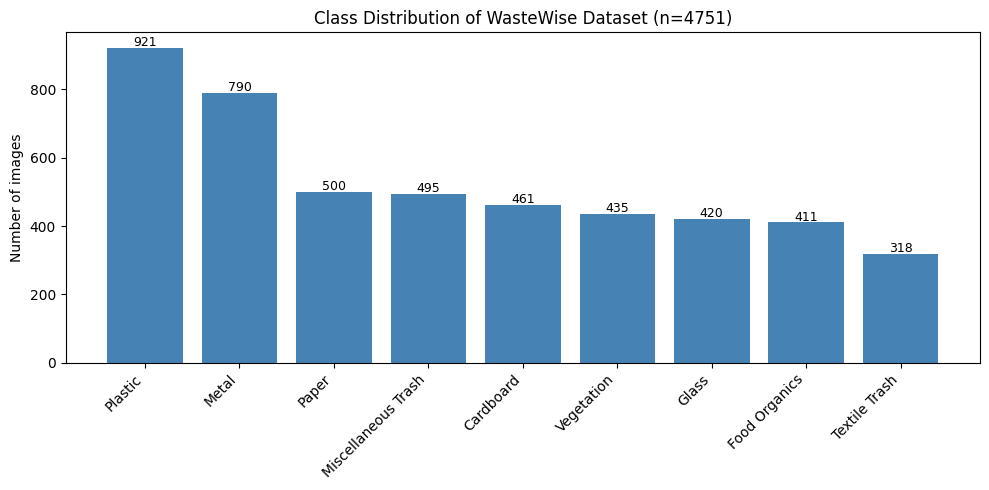

In [ ]:
counts = df_clean['label'].value_counts().sort_values(ascending=False)

# Class distribution bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values, color='steelblue')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 5,
             str(val), ha='center', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of images")
plt.title(f"Class Distribution of WasteWise Dataset (n={len(df_clean)})")
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()

In [ ]:

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Mean per class: {counts.mean():.0f}  |  Std: {counts.std():.0f}")

Imbalance ratio (max/min): 2.90
Mean per class: 528  |  Std: 196


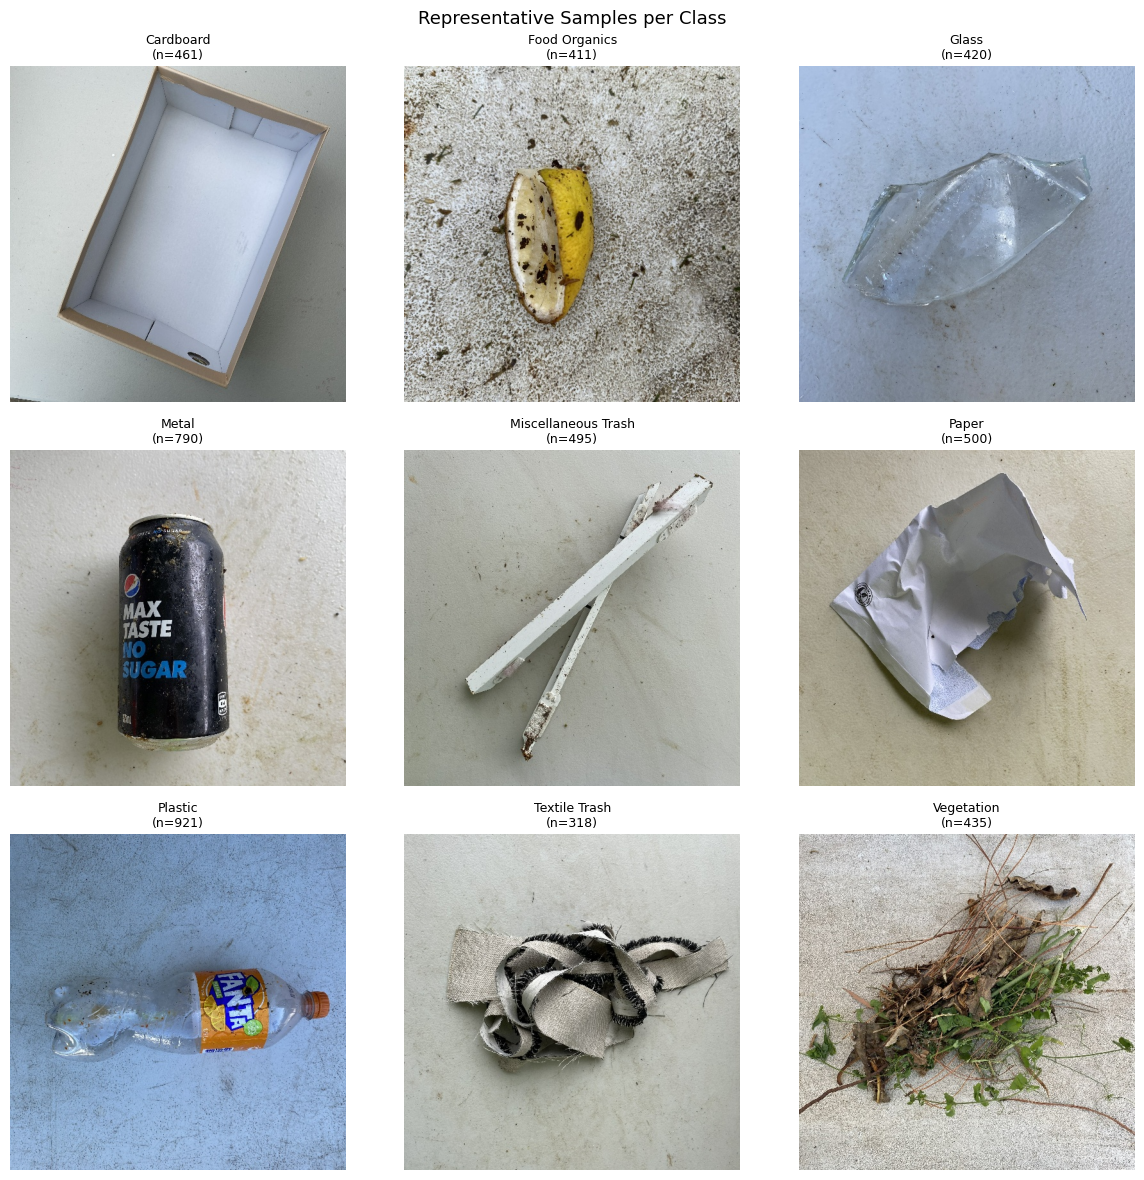

In [ ]:
# Representative grid, one per class
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, cls in zip(axes.flatten(), KNOWN_CLASSES):
    sample_path = df_clean[df_clean['label'] == cls]['filepath'].sample(
        1, random_state=SEED).values[0]
    ax.imshow(mpimg.imread(sample_path))
    ax.set_title(f"{cls}\n(n={counts[cls]})", fontsize=9)
    ax.axis('off')
plt.suptitle("Representative Samples per Class", fontsize=13)
plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150)
plt.show()

Image stats: 100%|██████████| 1500/1500 [00:09<00:00, 159.84it/s]


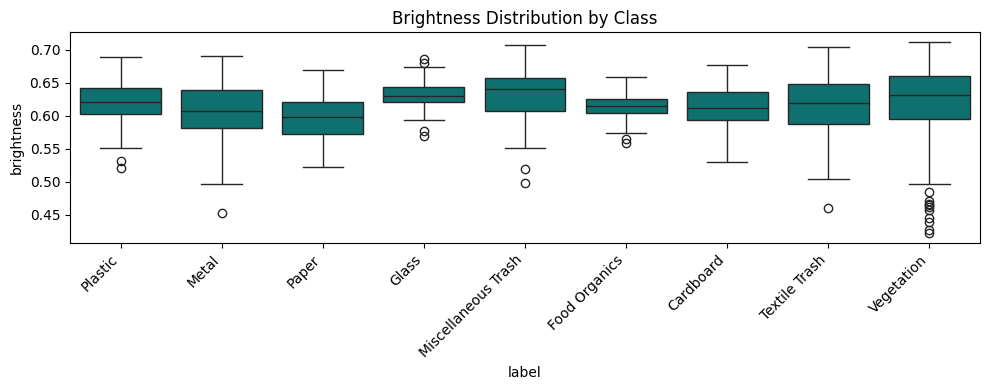

In [ ]:

# Per-image brightness / sharpness stats
def compute_image_stats(fp):
    arr = np.array(Image.open(fp).convert('RGB').resize((128, 128))) / 255.0
    brightness = arr.mean()
    gray = arr.mean(axis=2)
    gy, gx = np.gradient(gray)
    sharpness = (gx**2 + gy**2).mean()
    return arr.mean(axis=(0, 1)), brightness, sharpness

EDA_N = min(1500, len(df_clean))
eda_df = df_clean.sample(EDA_N, random_state=SEED).reset_index(drop=True)

computed = []
with ThreadPoolExecutor(max_workers=16) as ex:
    computed = list(tqdm(ex.map(compute_image_stats, eda_df['filepath']),
                         total=EDA_N, desc="Image stats"))

stats_rows = []
for (rgb, brightness, sharpness), label in zip(computed, eda_df['label']):
    stats_rows.append({'label': label,
                       'mean_r': rgb[0], 'mean_g': rgb[1], 'mean_b': rgb[2],
                       'brightness': brightness, 'sharpness': sharpness})
stats_df = pd.DataFrame(stats_rows)

plt.figure(figsize=(10, 4))
sns.boxplot(data=stats_df, x='label', y='brightness', color='teal')
plt.xticks(rotation=45, ha='right')
plt.title('Brightness Distribution by Class')
plt.tight_layout()
plt.savefig('eda_brightness.png', dpi=150)
plt.show()

#STRATIFIED SPLIT and CLASS WEIGHTS

Train: 3325  |  Val: 713  |  Test: 713
Class weights: {'Cardboard': np.float64(1.14), 'Food Organics': np.float64(1.28), 'Glass': np.float64(1.26), 'Metal': np.float64(0.67), 'Miscellaneous Trash': np.float64(1.07), 'Paper': np.float64(1.06), 'Plastic': np.float64(0.57), 'Textile Trash': np.float64(1.66), 'Vegetation': np.float64(1.22)}


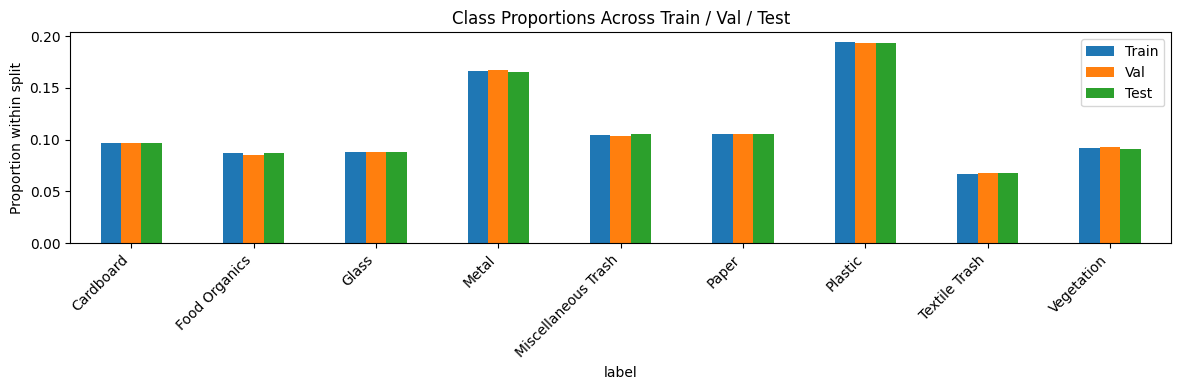

In [ ]:
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

CLASS_NAMES   = sorted(df_clean['label'].unique())
NUM_CLASSES   = len(CLASS_NAMES)
label_to_idx  = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_label  = {i: c for c, i in label_to_idx.items()}

for d in [train_df, val_df, test_df]:
    d['label_idx'] = d['label'].map(label_to_idx)

# Balanced class weights to counter imbalance
class_weights_arr = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=train_df['label_idx'])
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", {idx_to_label[k]: round(v, 2)
                         for k, v in class_weights.items()})

# Split proportion verification plot
split_counts = pd.DataFrame({
    'Train': train_df['label'].value_counts(normalize=True),
    'Val':   val_df['label'].value_counts(normalize=True),
    'Test':  test_df['label'].value_counts(normalize=True),
}).loc[CLASS_NAMES]
split_counts.plot(kind='bar', figsize=(12, 4))
plt.ylabel('Proportion within split')
plt.title('Class Proportions Across Train / Val / Test')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150)
plt.show()

# 3. DATA PIPELINES

In [ ]:
# Helper: safe decode that handles both JPEG and PNG
def safe_decode(raw_bytes):
    img = tf.image.decode_image(raw_bytes, channels=3,
                                expand_animations=False)
    img.set_shape([None, None, 3])
    return img

# CNN Pipeline (images stay in [0, 255]
def load_image_cnn(filepath, label):
    raw = tf.io.read_file(filepath)
    img = safe_decode(raw)                                    
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img = tf.cast(img, tf.float32)
    return img, label

def augment_cnn(img, label):
    """Standard augmentations — brightness on [0,255] so delta scaled correctly."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    # brightness delta 0.2 on [0,255] = ±51 px
    img = tf.image.random_brightness(img, max_delta=25.5)     # ≈ ±10% of 255
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_dataset_cnn(df, training=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['filepath'].values, df['label_idx'].values))
    ds = ds.map(load_image_cnn, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    if training:
        ds = ds.map(augment_cnn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds_cnn = make_dataset_cnn(train_df, training=True,  shuffle=True)
val_ds_cnn   = make_dataset_cnn(val_df,   training=False, shuffle=False)
test_ds_cnn  = make_dataset_cnn(test_df,  training=False, shuffle=False)


In [ ]:
# EfficientNetB3 Pipeline

def load_image_eff(filepath, label):
    raw = tf.io.read_file(filepath)
    img = safe_decode(raw)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)  # scales to EfficientNet range
    return img, label

def augment_eff(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    return img, label

def make_dataset_eff(df, training=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['filepath'].values, df['label_idx'].values))
    ds = ds.map(load_image_eff, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    if training:
        ds = ds.map(augment_eff, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds_eff = make_dataset_eff(train_df, training=True,  shuffle=True)
val_ds_eff   = make_dataset_eff(val_df,   training=False, shuffle=False)
test_ds_eff  = make_dataset_eff(test_df,  training=False, shuffle=False)